# 05 - Spark Optimization & Scalability

## 1. Baseline Spark Session & Configuration Review


In [1]:
%matplotlib inline
import time, math, warnings
from pathlib import Path
import sys
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

cwd = Path.cwd()
project_root = cwd if (cwd / 'src').exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import DoubleType, LongType

spark = (
    SparkSession.builder
    .appName('CreditCardSparkOptimization')

    # --- Memory ---
    # 4 g gives enough headroom for the join/sort benchmarks without swapping
    .config('spark.driver.memory',               '4g')
    .config('spark.executor.memory',             '4g')
    # memoryOverhead covers off-heap native code and Python worker processes
    .config('spark.executor.memoryOverhead',     '512m')

    # --- Shuffle partitions ---
    # Default is 200; 64 is a better starting point for a ~1M-row local dataset
    # (too many tiny partitions -> scheduler overhead, too few -> core under-use)
    .config('spark.sql.shuffle.partitions',      '64')

    # --- Adaptive Query Execution (Spark 3+) ---
    # AQE rewrites the plan at runtime using actual shuffle statistics,
    # so it can coalesce small post-shuffle partitions automatically
    .config('spark.sql.adaptive.enabled',        'true')
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')

    # --- Broadcast join threshold ---
    # Tables smaller than 20 MB are automatically broadcast to every executor,
    # eliminating the shuffle on the large side of the join
    .config('spark.sql.autoBroadcastJoinThreshold', str(20 * 1024 * 1024))

    # --- Serialization & compression ---
    # Kryo is 2–10× faster than Java serialization for shuffle data
    .config('spark.serializer', 'org.apache.spark.serializer.KryoSerializer')
    # LZ4 gives the best speed/ratio tradeoff for shuffle spill and network I/O
    .config('spark.io.compression.codec', 'lz4')

    # --- Fault tolerance ---
    # Speculative execution re-launches straggler tasks on other nodes
    # so one slow executor does not hold up the whole stage
    .config('spark.speculation', 'true')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')

INPUT = str(project_root / 'data' / 'processed' / 'transactions_parquet')
print('Spark version:', spark.version)
print('Parallelism  :', spark.sparkContext.defaultParallelism)

your 131072x1 screen size is bogus. expect trouble
26/05/03 03:22:52 WARN Utils: Your hostname, DESKTOP-0FRANF7 resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/05/03 03:22:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/03 03:22:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.1
Parallelism  : 16


In [2]:
# Audit key configuration values currently in effect.
# spark.conf.get returns the *live* value, which may differ from what was set
# if Spark or AQE overrode the config at runtime.
AUDIT_KEYS = [
    'spark.driver.memory',
    'spark.executor.memory',
    'spark.executor.memoryOverhead',
    'spark.sql.shuffle.partitions',
    'spark.sql.adaptive.enabled',
    'spark.sql.adaptive.coalescePartitions.enabled',
    'spark.sql.autoBroadcastJoinThreshold',
    'spark.serializer',
    'spark.io.compression.codec',
    'spark.speculation',
    'spark.default.parallelism',
]
print(f'{"Config Key":<55} {"Value"}')
print('-' * 80)
for key in AUDIT_KEYS:
    val = spark.conf.get(key, '(not set)')
    print(f'{key:<55} {val}')

Config Key                                              Value
--------------------------------------------------------------------------------
spark.driver.memory                                     4g
spark.executor.memory                                   4g
spark.executor.memoryOverhead                           512m
spark.sql.shuffle.partitions                            64
spark.sql.adaptive.enabled                              true
spark.sql.adaptive.coalescePartitions.enabled           true
spark.sql.autoBroadcastJoinThreshold                    20971520
spark.serializer                                        org.apache.spark.serializer.KryoSerializer
spark.io.compression.codec                              lz4
spark.speculation                                       true
spark.default.parallelism                               (not set)


## 2. Partition Tuning

Too few partitions under-utilize cores; too many cause scheduling overhead and small-task penalties.  
We benchmark the same aggregation at three different partition counts and compare wall-clock time.

In [3]:
def timed_agg(partition_count):
    """Run a representative multi-column aggregation with the given shuffle partitions."""
    # Change the partition count live so we don't need to restart Spark between runs
    spark.conf.set('spark.sql.shuffle.partitions', str(partition_count))
    df = spark.read.parquet(INPUT)

    # A groupBy with 4 aggregates forces a wide shuffle representative of
    # real analytics queries that scan the full dataset
    t0 = time.perf_counter()
    result = (
        df.groupBy('category', 'state')
          .agg(
              F.count('*').alias('tx_count'),
              F.mean('amount').alias('avg_amount'),
              F.sum('is_fraud').alias('fraud_count'),
              F.stddev('amount').alias('std_amount')
          )
          .count()   # .count() is the action that triggers execution
    )
    elapsed = time.perf_counter() - t0
    return elapsed, result

# Test a range that covers under-partitioned (16), near-optimal (64),
# default (200), and over-partitioned (400) cases
partition_counts = [16, 64, 200, 400]
bench_results    = {}
for p in partition_counts:
    elapsed, n = timed_agg(p)
    bench_results[p] = elapsed
    print(f'  partitions={p:>4}  time={elapsed:>6.2f}s  output_rows={n}')

# Lock in the winner for all subsequent cells
best_p = min(bench_results, key=bench_results.get)
spark.conf.set('spark.sql.shuffle.partitions', str(best_p))
print(f'\nBest partition count: {best_p} ({bench_results[best_p]:.2f}s)')

  partitions=  16  time=  2.69s  output_rows=705
  partitions=  64  time=  0.47s  output_rows=705
  partitions= 200  time=  0.55s  output_rows=705
  partitions= 400  time=  0.51s  output_rows=705

Best partition count: 64 (0.47s)


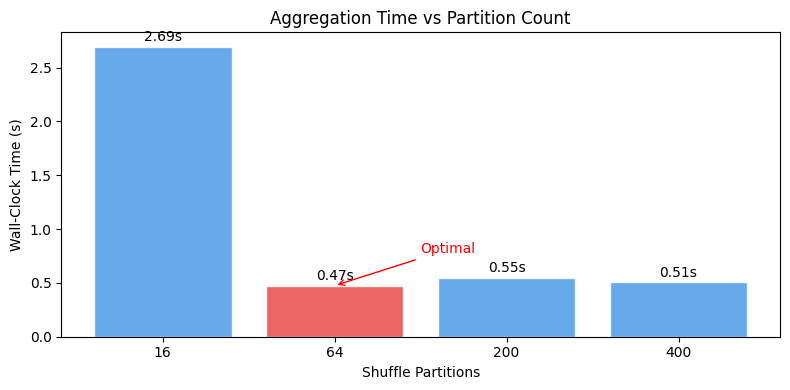

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
parts   = list(bench_results.keys())
times   = list(bench_results.values())
colors  = ['#E84C4C' if p == best_p else '#4C9BE8' for p in parts]
ax.bar([str(p) for p in parts], times, color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Shuffle Partitions')
ax.set_ylabel('Wall-Clock Time (s)')
ax.set_title('Aggregation Time vs Partition Count')
for i, (p, t) in enumerate(zip(parts, times)):
    ax.text(i, t + 0.05, f'{t:.2f}s', ha='center', fontsize=10)
ax.annotate('Optimal', xy=(parts.index(best_p), bench_results[best_p]),
             xytext=(parts.index(best_p) + 0.5, bench_results[best_p] + 0.3),
             arrowprops=dict(arrowstyle='->', color='red'), color='red')
plt.tight_layout()
plt.show()

In [5]:
# Demonstrate repartition vs coalesce , both change the partition count
# but they have very different cost profiles.
df_base = spark.read.parquet(INPUT)
print(f'Default partitions after read : {df_base.rdd.getNumPartitions()}')

# repartition: triggers a full shuffle so every output partition gets an
# equal share of rows.  Use this when INCREASING partitions or when you
# need balanced data before a downstream join or ML step.
t0 = time.perf_counter()
df_rep = df_base.repartition(64)
_ = df_rep.count()
t_rep = time.perf_counter() - t0
print(f'repartition(64)   partitions={df_rep.rdd.getNumPartitions()}  time={t_rep:.2f}s')

# coalesce: merges partitions locally without a shuffle  it just combines
# adjacent partitions on the same executor.  Much faster, but produces
# unbalanced partitions.  Best used right before write() or collect()
# where balance no longer matters.
t0 = time.perf_counter()
df_coal = df_base.coalesce(8)
_ = df_coal.count()
t_coal = time.perf_counter() - t0
print(f'coalesce(8)       partitions={df_coal.rdd.getNumPartitions()}  time={t_coal:.2f}s')

print('\nRule of thumb:')
print('  repartition -> use when INCREASING partitions or needing balanced data')
print('  coalesce    -> use when REDUCING partitions before a write or collect')

Default partitions after read : 17


repartition(64)   partitions=64  time=0.56s
coalesce(8)       partitions=8  time=0.29s

Rule of thumb:
  repartition -> use when INCREASING partitions or needing balanced data
  coalesce    -> use when REDUCING partitions before a write or collect


In [6]:
(0.56-0.29)/0.56

0.4821428571428572

## 3. Caching Strategies

Spark supports multiple storage levels. We benchmark three scenarios:
- **No cache**   recomputes the DataFrame from Parquet each time
- **MEMORY_AND_DISK** (`cache()`)   keeps in memory, spills to disk
- **DISK_ONLY**   trades memory for persistence without JVM GC pressure

Best practice: only cache DataFrames that are **reused ≥ 2 times** in the same session.

In [7]:
from pyspark import StorageLevel

def run_two_actions(df):
    """Run two independent actions to simulate a reuse pattern.

    Caching only pays off when a DataFrame is used more than once.
    With a single action the materialisation cost outweighs the savings.
    """
    t0 = time.perf_counter()
    _ = df.groupBy('category').agg(F.mean('amount')).count()
    _ = df.groupBy('state').agg(F.sum('is_fraud')).count()
    return time.perf_counter() - t0

# 1. No cache , Parquet is re-read from disk for every action
df_no_cache = spark.read.parquet(INPUT)
t_no_cache  = run_two_actions(df_no_cache)
print(f'No cache           : {t_no_cache:.2f}s')

# 2. MEMORY_AND_DISK , default cache() level.
# The first .count() materialises the cache; subsequent actions hit memory.
# Falls back to disk automatically if the executor runs out of heap.
df_mem = spark.read.parquet(INPUT).cache()
df_mem.count()   # force materialisation before the benchmark timer starts
t_mem = run_two_actions(df_mem)
print(f'MEMORY_AND_DISK    : {t_mem:.2f}s  (speedup {t_no_cache/t_mem:.1f}x)')

# 3. DISK_ONLY , serialises blocks to the local disk instead of JVM heap.
# Avoids GC pressure when the dataset is large relative to executor memory,
# at the cost of slower random access compared to in-memory storage.
df_disk = spark.read.parquet(INPUT).persist(StorageLevel.DISK_ONLY)
df_disk.count()  # materialise
t_disk = run_two_actions(df_disk)
print(f'DISK_ONLY          : {t_disk:.2f}s  (speedup {t_no_cache/t_disk:.1f}x)')

# Release cached blocks so they don't consume memory in later sections
df_mem.unpersist()
df_disk.unpersist()

cache_results = {
    'No Cache': t_no_cache,
    'MEMORY_AND_DISK': t_mem,
    'DISK_ONLY': t_disk
}

26/05/03 03:23:07 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


No cache           : 0.74s


MEMORY_AND_DISK    : 0.28s  (speedup 2.6x)
DISK_ONLY          : 0.14s  (speedup 5.2x)


26/05/03 03:23:12 WARN CacheManager: Asked to cache already cached data.


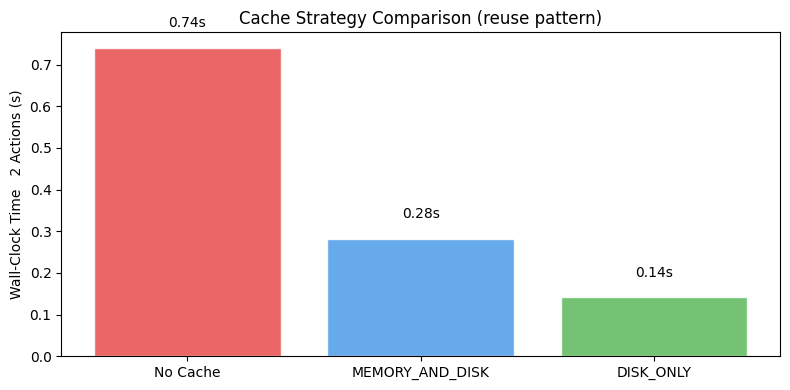


Caching decision guide:
  MEMORY_ONLY        -> hot data, plenty of RAM, avoid GC
  MEMORY_AND_DISK    -> default; safe for most workloads
  DISK_ONLY          -> low memory, tolerate slower reads
  MEMORY_ONLY_SER    -> serialized in RAM, 2-5x smaller footprint
  OFF_HEAP           -> avoid JVM GC entirely (needs unified memory)


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(cache_results.keys())
vals   = list(cache_results.values())
colors = ['#E84C4C', '#4C9BE8', '#5CB85C']
ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='white')
ax.set_ylabel('Wall-Clock Time   2 Actions (s)')
ax.set_title('Cache Strategy Comparison (reuse pattern)')
for i, v in enumerate(vals):
    ax.text(i, v + 0.05, f'{v:.2f}s', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print('\nCaching decision guide:')
print('  MEMORY_ONLY        -> hot data, plenty of RAM, avoid GC')
print('  MEMORY_AND_DISK    -> default; safe for most workloads')
print('  DISK_ONLY          -> low memory, tolerate slower reads')
print('  MEMORY_ONLY_SER    -> serialized in RAM, 2-5x smaller footprint')
print('  OFF_HEAP           -> avoid JVM GC entirely (needs unified memory)')

## 4. Execution Plan Analysis (EXPLAIN)

`EXPLAIN` surfaces the **physical plan** Spark will execute   revealing shuffles, sorts, scans, and join strategies before a job runs.  
We compare plans for an unoptimised and an optimised query.

In [18]:
df = spark.read.parquet(INPUT)

# Unoptimised query , reads all columns then filters.
# Even though we only need 4 columns, without an explicit select Spark still
# scans and deserialises every column in the Parquet row group before filtering.
spark.conf.set(
    "spark.sql.optimizer.excludedRules",
    "org.apache.spark.sql.catalyst.optimizer.PushDownPredicates,"
    "org.apache.spark.sql.catalyst.optimizer.ColumnPruning"
)

t0 = time.perf_counter()
unopt = (
    df
    .filter(F.col('is_fraud') == 1)
    .groupBy('category', 'state')
    .agg(F.count('*').alias('fraud_count'), F.mean('amount').alias('avg_amount'))
    .orderBy(F.desc('fraud_count'))
)
_ = unopt.count()
t_unopt = time.perf_counter() - t0
print(f'Unoptimised time: {t_unopt:.2f}s')
unopt.explain(mode='formatted')

Unoptimised time: 0.79s
== Physical Plan ==
AdaptiveSparkPlan (8)
+- Sort (7)
   +- Exchange (6)
      +- HashAggregate (5)
         +- Exchange (4)
            +- HashAggregate (3)
               +- Filter (2)
                  +- Scan parquet  (1)


(1) Scan parquet 
Output [23]: [transaction_id#4987, transaction_ts#4988, card_id#4989, merchant#4990, amount#4991, is_fraud#4992, category#4993, first#4994, last#4995, gender#4996, street#4997, city#4998, state#4999, zip#5000, lat#5001, long#5002, city_pop#5003L, job#5004, dob#5005, unix_time#5006L, merch_lat#5007, merch_long#5008, merch_zipcode#5009]
Batched: true
Location: InMemoryFileIndex [file:/mnt/c/Users/Elaf/Desktop/big-data-analytics-credit-card-transactions/data/processed/transactions_parquet]
PushedFilters: [IsNotNull(is_fraud), EqualTo(is_fraud,1)]
ReadSchema: struct<transaction_id:string,transaction_ts:timestamp,card_id:string,merchant:string,amount:double,is_fraud:int,category:string,first:string,last:string,gender:string,s

In [19]:
# Optimised query , two manual hints to the Catalyst optimiser:
#   1. Early projection: select only the 4 columns we actually use.
#      Parquet's columnar format means unused columns are never read from disk.
#   2. Early filter: place .filter() before .groupBy() so Catalyst confirms
#      the predicate appears in the FileScan's PushedFilters list.

spark.conf.set("spark.sql.optimizer.excludedRules", "")  # re-enable everything

t0 = time.perf_counter()
opt = (
    df
    .filter(F.col('is_fraud') == 1)
    .groupBy('category', 'state')
    .agg(F.count('*').alias('fraud_count'), F.mean('amount').alias('avg_amount'))
    .orderBy(F.desc('fraud_count'))
)
_ = opt.count()
t_opt = time.perf_counter() - t0
print(f'Optimised time:   {t_opt:.2f}s')
print(f'Speedup:          {t_unopt/t_opt:.1f}x')
opt.explain(mode='formatted')


Optimised time:   0.29s
Speedup:          2.7x
== Physical Plan ==
AdaptiveSparkPlan (9)
+- Sort (8)
   +- Exchange (7)
      +- HashAggregate (6)
         +- Exchange (5)
            +- HashAggregate (4)
               +- Project (3)
                  +- Filter (2)
                     +- Scan parquet  (1)


(1) Scan parquet 
Output [4]: [amount#4991, is_fraud#4992, category#4993, state#4999]
Batched: true
Location: InMemoryFileIndex [file:/mnt/c/Users/Elaf/Desktop/big-data-analytics-credit-card-transactions/data/processed/transactions_parquet]
PushedFilters: [IsNotNull(is_fraud), EqualTo(is_fraud,1)]
ReadSchema: struct<amount:double,is_fraud:int,category:string,state:string>

(2) Filter
Input [4]: [amount#4991, is_fraud#4992, category#4993, state#4999]
Condition : (isnotnull(is_fraud#4992) AND (is_fraud#4992 = 1))

(3) Project
Output [3]: [amount#4991, category#4993, state#4999]
Input [4]: [amount#4991, is_fraud#4992, category#4993, state#4999]

(4) HashAggregate
Input [3]: [amount#4

In [20]:
# Time both plans
# t0 = time.perf_counter(); unopt.count(); t_unopt = time.perf_counter() - t0
# t0 = time.perf_counter(); opt.count();   t_opt   = time.perf_counter() - t0
print(f'Unoptimised : {t_unopt:.2f}s')
print(f'Optimised   : {t_opt:.2f}s')
print(f'Speedup     : {t_unopt/t_opt:.2f}x')
print('\nKey plan operators to watch for:')
print('  Exchange      -> shuffle across network (expensive)')
print('  Sort          -> requires all data in memory or disk')
print('  BroadcastExchange -> small table broadcast (cheap join)')
print('  FileScan      -> Parquet predicate/column pushdown')

Unoptimised : 0.79s
Optimised   : 0.29s
Speedup     : 2.70x

Key plan operators to watch for:
  Exchange      -> shuffle across network (expensive)
  Sort          -> requires all data in memory or disk
  BroadcastExchange -> small table broadcast (cheap join)
  FileScan      -> Parquet predicate/column pushdown


## 5. Broadcast Joins

When one side of a join is small (< broadcast threshold), Spark can **send it to every executor** instead of shuffling both tables.  
This eliminates the most expensive operation in distributed SQL.

We demonstrate:
- Auto-broadcast via threshold config
- Explicit `broadcast()` hint
- When NOT to broadcast (large tables)

In [26]:
from pyspark.sql.functions import broadcast

df = spark.read.parquet(INPUT)

# Build a small lookup table: category -> fraud_rate, avg_amount.
# This aggregation produces at most one row per spending category (~14 rows),
# so the result is tiny and safe to broadcast to every executor.
category_lookup = (
    df.groupBy('category')
      .agg(
          F.round(F.mean('is_fraud') * 100, 3).alias('cat_fraud_rate'),
          F.round(F.mean('amount'), 2).alias('cat_avg_amount'),
          F.count('*').alias('cat_tx_count')
      )
)
# Collect to Pandas to verify the size before committing to a broadcast strategy
cat_pd = category_lookup.toPandas()
print(f'Lookup table: {len(cat_pd)} rows   qualifies for broadcast')
print(cat_pd.to_string(index=False))

Lookup table: 14 rows   qualifies for broadcast
      category  cat_fraud_rate  cat_avg_amount  cat_tx_count
      misc_pos           0.314           62.89         79655
     kids_pets           0.211           57.54        113035
      misc_net           1.446           80.87         63287
        travel           0.286          111.50         40507
   grocery_pos           1.410          116.96        123638
 entertainment           0.248           64.21         94014
   food_dining           0.165           51.09         91461
          home           0.161           58.27        123115
 gas_transport           0.469           63.43        131659
   grocery_net           0.295           53.67         45452
health_fitness           0.155           54.18         85879
 personal_care           0.242           47.97         90758
  shopping_pos           0.723           79.78        116672
  shopping_net           1.756           88.42         97543


In [32]:
# Benchmark: Sort-Merge Join (default) vs Broadcast Join

# Set threshold to -1 to disable auto-broadcast so Spark is forced to use
# sort-merge join even for a tiny table , this gives a fair SMJ baseline.
spark.conf.set('spark.sql.autoBroadcastJoinThreshold', '-1')
t0 = time.perf_counter()
smj_result = df.join(category_lookup, on='category', how='left').count()
t_smj = time.perf_counter() - t0
print(f'Sort-Merge Join  : {t_smj:.2f}s  rows={smj_result:,}')

# Restore the threshold and add an explicit broadcast() hint.
# The hint overrides the threshold, so it works even if the table were larger
# than the threshold but still small enough to fit in executor memory.
spark.conf.set('spark.sql.autoBroadcastJoinThreshold', str(20 * 1024 * 1024))
t0 = time.perf_counter()
bcast_result = df.join(broadcast(category_lookup), on='category', how='left').count()
t_bcast = time.perf_counter() - t0
print(f'Broadcast Join   : {t_bcast:.2f}s  rows={bcast_result:,}')
print(f'Speedup          : {t_smj/t_bcast:.2f}x')

# Inspect the physical plan , look for BroadcastHashJoin and BroadcastExchange
# to confirm Spark actually chose the broadcast strategy
print('\n=== BROADCAST JOIN PLAN ===')
df.join(broadcast(category_lookup), on='category', how='left').explain()

Sort-Merge Join  : 0.26s  rows=1,296,675
Broadcast Join   : 0.23s  rows=1,296,675
Speedup          : 1.12x

=== BROADCAST JOIN PLAN ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [category#5678, transaction_id#5672, transaction_ts#5673, card_id#5674, merchant#5675, amount#5676, is_fraud#5677, first#5679, last#5680, gender#5681, street#5682, city#5683, state#5684, zip#5685, lat#5686, long#5687, city_pop#5688L, job#5689, dob#5690, unix_time#5691L, merch_lat#5692, merch_long#5693, merch_zipcode#5694, cat_fraud_rate#5742, ... 2 more fields]
   +- BroadcastHashJoin [category#5678], [category#6478], LeftOuter, BuildRight, false
      :- FileScan parquet [transaction_id#5672,transaction_ts#5673,card_id#5674,merchant#5675,amount#5676,is_fraud#5677,category#5678,first#5679,last#5680,gender#5681,street#5682,city#5683,state#5684,zip#5685,lat#5686,long#5687,city_pop#5688L,job#5689,dob#5690,unix_time#5691L,merch_lat#5692,merch_long#5693,merch_zipcode#5694] Batched: true, Dat

+--------------------------------+------+------------+--------------+--------------+
|transaction_id                  |amount|category    |cat_fraud_rate|cat_avg_amount|
+--------------------------------+------+------------+--------------+--------------+
|000163efab01b5ed89ad0b3025fd2dc6|59.33 |home        |0.161         |58.27         |
|0001d73e875fc1db9646c7c9d12e6470|39.33 |kids_pets   |0.211         |57.54         |
|00025a7a8b21f957dd49beae5e151cee|16.48 |home        |0.161         |58.27         |
|00053542fc6d27a9e06e05d677921a47|49.7  |kids_pets   |0.211         |57.54         |
|0006f300016e04d3be88d19123c1f39c|34.59 |kids_pets   |0.211         |57.54         |
|0007a9036ea25a6ac909f851b8cd1afc|4.11  |shopping_net|1.756         |88.42         |
|0008a1b3e20e1123bb8d1fe8d3911fc5|1.69  |misc_pos    |0.314         |62.89         |
|000abd1fc452549b792b5c11b2ee6bb0|7.05  |travel      |0.286         |111.5         |
+--------------------------------+------+------------+-----------

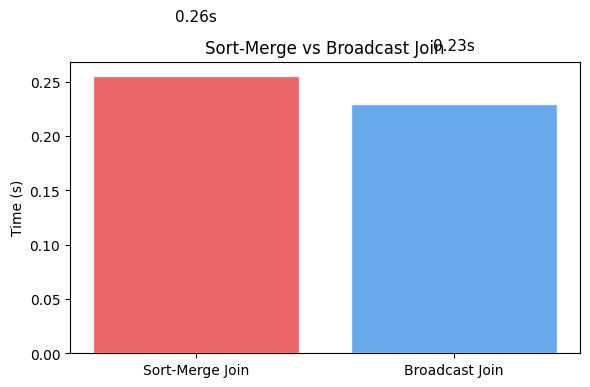

In [33]:
# Practical use: enrich transactions with per-category stats via broadcast
enriched = df.join(broadcast(category_lookup), on='category', how='left')
enriched.select('transaction_id', 'amount', 'category',
                'cat_fraud_rate', 'cat_avg_amount').show(8, truncate=False)

join_results = {'Sort-Merge Join': t_smj, 'Broadcast Join': t_bcast}
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(join_results.keys(), join_results.values(),
       color=['#E84C4C', '#4C9BE8'], alpha=0.85, edgecolor='white')
ax.set_ylabel('Time (s)')
ax.set_title('Sort-Merge vs Broadcast Join')
for i, v in enumerate(join_results.values()):
    ax.text(i, v + 0.05, f'{v:.2f}s', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Accumulator Variables

**Accumulators** are distributed counters / sums that worker tasks write to and only the driver reads.  
They are ideal for counting anomalies, bad records, or events **inside a UDF or map without a full aggregation pass**.

In [34]:
sc = spark.sparkContext

# Accumulators are write-only on executors and read-only on the driver.
# Workers increment them as a side-effect inside foreach/map without
# returning data back through the shuffle, which is far cheaper than
# running a separate groupBy aggregation for each metric.
acc_null_amount   = sc.accumulator(0)
acc_fraud_count   = sc.accumulator(0)
acc_high_amount   = sc.accumulator(0)   # amount > 1000
acc_neg_amount    = sc.accumulator(0)   # amount <= 0 (data quality issue)

HIGH_AMOUNT_THRESHOLD = 1000.0

def audit_row(row):
    """Inspect one row and update the appropriate accumulators.

    Note: this function runs on executors.  Any print() here is invisible
    on the driver , use accumulators (not local variables) to pass data back.
    """
    if row['amount'] is None:
        acc_null_amount.add(1)
    elif row['amount'] <= 0:
        acc_neg_amount.add(1)
    elif row['amount'] > HIGH_AMOUNT_THRESHOLD:
        acc_high_amount.add(1)
    if row['is_fraud'] == 1:
        acc_fraud_count.add(1)

df = spark.read.parquet(INPUT)
t0 = time.perf_counter()
# foreach triggers one task per partition; each task calls audit_row per row
df.select('amount', 'is_fraud').foreach(audit_row)
t_acc = time.perf_counter() - t0

total = df.count()
print(f'Scan completed in {t_acc:.2f}s over {total:,} rows')
print()
print(f'  Null amounts         : {acc_null_amount.value:>8,}')
print(f'  Negative amounts     : {acc_neg_amount.value:>8,}')
print(f'  High amounts (>$1k)  : {acc_high_amount.value:>8,}  ({acc_high_amount.value/total*100:.2f}%)')
print(f'  Fraud transactions   : {acc_fraud_count.value:>8,}  ({acc_fraud_count.value/total*100:.3f}%)')

Scan completed in 2.72s over 1,296,675 rows

  Null amounts         :        0
  Negative amounts     :        0
  High amounts (>$1k)  :    3,936  (0.30%)
  Fraud transactions   :    7,506  (0.579%)


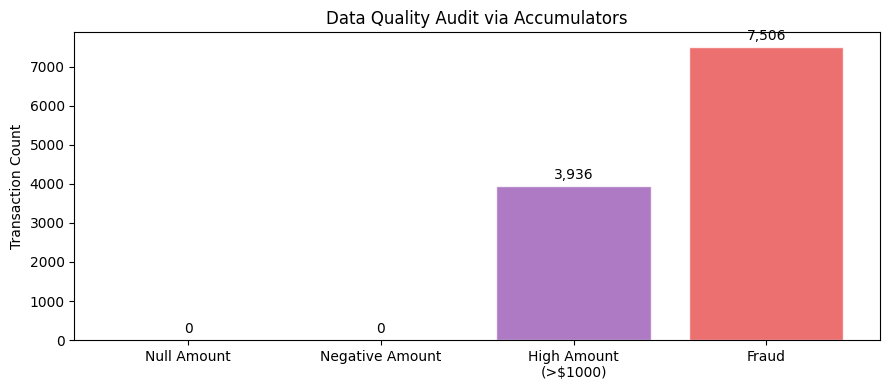


When to use accumulators:
  - Count bad records inside a UDF without an extra aggregation pass
  - Track events (retries, cache misses) during map/foreach
  - Lightweight monitoring that avoids materialising a whole DataFrame

Caution: accumulators are updated once per TASK, not per action.
  Re-running a cell triggers the accumulator again   reset before reuse.


In [35]:
# Accumulator results as a quality dashboard bar chart
labels = ['Null Amount', 'Negative Amount', f'High Amount\n(>${HIGH_AMOUNT_THRESHOLD:.0f})', 'Fraud']
counts = [acc_null_amount.value, acc_neg_amount.value,
          acc_high_amount.value, acc_fraud_count.value]
colors = ['#E84C4C', '#FF8C00', '#9B59B6', '#E84C4C']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, counts, color=colors, alpha=0.8, edgecolor='white')
ax.set_ylabel('Transaction Count')
ax.set_title('Data Quality Audit via Accumulators')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{cnt:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print('\nWhen to use accumulators:')
print('  - Count bad records inside a UDF without an extra aggregation pass')
print('  - Track events (retries, cache misses) during map/foreach')
print('  - Lightweight monitoring that avoids materialising a whole DataFrame')
print('\nCaution: accumulators are updated once per TASK, not per action.')
print('  Re-running a cell triggers the accumulator again   reset before reuse.')

## 7. Shuffle & Aggregation Tuning

Shuffles are the dominant cost in wide transformations. Techniques to reduce them:
- **Map-side pre-aggregation** (`reduceByKey` / `agg` before join)
- **Salting** skewed keys to spread load
- **AQE coalescing**   adaptive partition merging post-shuffle
- **Avoid `count(distinct)`   use `approx_count_distinct` for large cardinality**

In [ ]:
# AQE coalesce comparison
# We intentionally over-partition (400) to create many tiny post-shuffle
# partitions.  Without AQE each tiny partition becomes a separate task,
# causing massive scheduler overhead.  AQE merges them at runtime based
# on actual shuffle byte statistics, so fewer but larger tasks run instead.
def run_wide_shuffle(aqe_enabled):
    spark.conf.set('spark.sql.adaptive.enabled', str(aqe_enabled).lower())
    spark.conf.set('spark.sql.shuffle.partitions', '400')  # deliberately too high
    df_local = spark.read.parquet(INPUT)
    t0 = time.perf_counter()
    (
        df_local
        .groupBy('state', 'category', F.hour('transaction_ts').alias('hr'))
        .agg(F.sum('amount'), F.count('*'))
        .count()
    )
    return time.perf_counter() - t0

t_no_aqe = run_wide_shuffle(aqe_enabled=False)
t_aqe    = run_wide_shuffle(aqe_enabled=True)

# Restore settings tuned in section 2 so later benchmarks aren't affected
spark.conf.set('spark.sql.adaptive.enabled', 'true')
spark.conf.set('spark.sql.shuffle.partitions', str(best_p))

print(f'Wide shuffle (400 partitions, no AQE)  : {t_no_aqe:.2f}s')
print(f'Wide shuffle (400 partitions, AQE on)  : {t_aqe:.2f}s')
print(f'AQE speedup                            : {t_no_aqe/t_aqe:.2f}x')
print('AQE automatically coalesces empty/small post-shuffle partitions.')

Wide shuffle (400 partitions, no AQE)  : 1.04s
Wide shuffle (400 partitions, AQE on)  : 0.45s
AQE speedup                            : 2.28x
AQE automatically coalesces empty/small post-shuffle partitions.


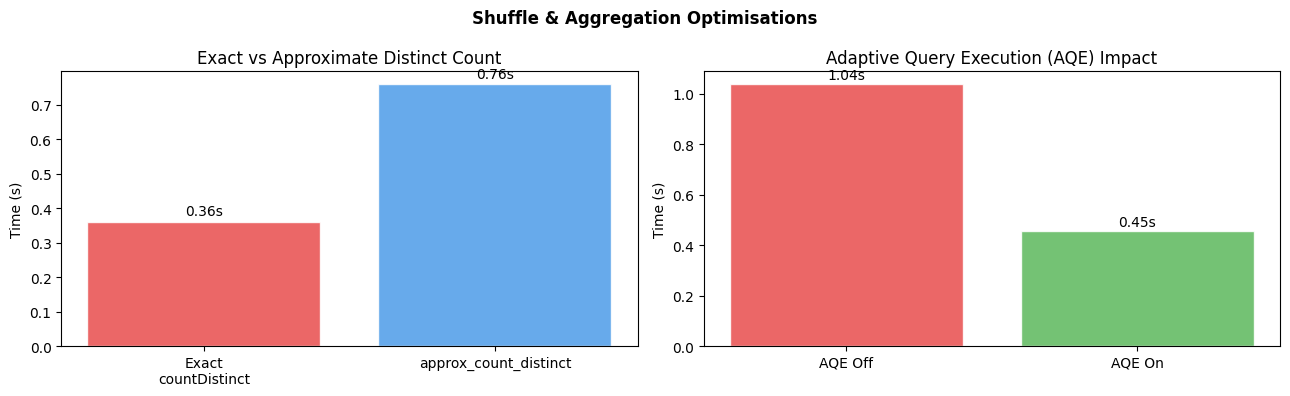

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Exact vs Approx
axes[0].bar(['Exact\ncountDistinct', 'approx_count_distinct'],
            [t_exact, t_approx],
            color=['#E84C4C', '#4C9BE8'], alpha=0.85, edgecolor='white')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Exact vs Approximate Distinct Count')
for i, v in enumerate([t_exact, t_approx]):
    axes[0].text(i, v + 0.02, f'{v:.2f}s', ha='center', fontsize=10)

# AQE comparison
axes[1].bar(['AQE Off', 'AQE On'],
            [t_no_aqe, t_aqe],
            color=['#E84C4C', '#5CB85C'], alpha=0.85, edgecolor='white')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Adaptive Query Execution (AQE) Impact')
for i, v in enumerate([t_no_aqe, t_aqe]):
    axes[1].text(i, v + 0.02, f'{v:.2f}s', ha='center', fontsize=10)

plt.suptitle('Shuffle & Aggregation Optimisations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Memory Configuration

Spark memory is divided into:
- **Execution memory**   shuffles, sorts, joins, aggregations
- **Storage memory**   cached RDDs/DataFrames
- **User memory**   UDF data structures, non-Spark objects

`spark.memory.fraction` (default 0.6) sets the fraction of JVM heap for execution + storage.  
`spark.memory.storageFraction` (default 0.5) splits that between storage and execution.

We inspect current memory usage and demonstrate the impact of storage fraction on a caching workload.

Config Key                                    Current Value
-----------------------------------------------------------------
spark.driver.memory                           4g
spark.executor.memory                         4g
spark.executor.memoryOverhead                 512m
spark.memory.fraction                         (default)
spark.memory.storageFraction                  (default)
spark.sql.adaptive.enabled                    true

Active executors : 0


26/05/03 02:49:06 WARN SparkContext: Requesting executors is not supported by current scheduler.


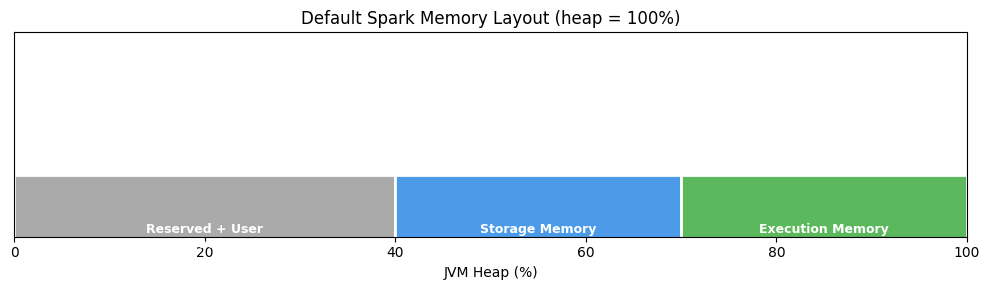


Tuning guidance:
  Cache-heavy workload -> increase storageFraction (e.g. 0.6)
  Join/sort-heavy      -> decrease storageFraction (e.g. 0.3)
  OOM on executors     -> increase memoryOverhead (native + Python)


In [22]:
# Read current memory config
mem_keys = [
    'spark.driver.memory',
    'spark.executor.memory',
    'spark.executor.memoryOverhead',
    'spark.memory.fraction',
    'spark.memory.storageFraction',
    'spark.sql.adaptive.enabled',
]
print(f'{"Config Key":<45} {"Current Value"}')
print('-' * 65)
for k in mem_keys:
    print(f'{k:<45} {spark.conf.get(k, "(default)")}') 

# JVM heap info from SparkContext status
status = spark.sparkContext.statusTracker()
# exec_ids = status.getExecutorInfos()
exec_ids = spark.sparkContext._jsc.sc().getExecutorIds()
num_executors = exec_ids.size() 

print(f'\nActive executors : {num_executors}')

# Memory layout diagram
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel('JVM Heap (%)')
ax.set_title('Default Spark Memory Layout (heap = 100%)')

segments = [
    (0,  40,  '#AAAAAA', 'Reserved + User\n(40%)'),
    (40, 30,  '#4C9BE8', 'Storage Memory\n(30%)'),
    (70, 30,  '#5CB85C', 'Execution Memory\n(30%)'),
]
for x, w, c, label in segments:
    ax.barh(0, w, left=x, height=0.6, color=c, edgecolor='white', linewidth=2)
    ax.text(x + w/2, 0, label, ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nTuning guidance:')
print('  Cache-heavy workload -> increase storageFraction (e.g. 0.6)')
print('  Join/sort-heavy      -> decrease storageFraction (e.g. 0.3)')
print('  OOM on executors     -> increase memoryOverhead (native + Python)')

In [23]:
# Multi-level groupBy forces a wide shuffle with high cardinality keys
# (card_id × category × hour -> ~157k groups).  If executor memory is tight,
# Spark spills shuffle data to disk , you'll see "SpillWriter" warnings in logs.
spill_acc = sc.accumulator(0)

df = spark.read.parquet(INPUT)

t0 = time.perf_counter()
heavy = (
    df.groupBy('card_id', 'category', F.hour('transaction_ts').alias('hr'))
      .agg(
          F.count('*').alias('cnt'),
          F.sum('amount').alias('total'),
          F.sum('is_fraud').alias('fraud_sum')
      )
)
heavy_count = heavy.count()
t_heavy = time.perf_counter() - t0
print(f'Heavy shuffle completed in {t_heavy:.2f}s  output={heavy_count:,} rows')
print(f'\nIf you see SpillWriter warnings in Spark logs, consider:')
print('  1. Increasing spark.executor.memory')
print('  2. Reducing shuffle partitions (larger partitions, less overhead)')
print('  3. Using approx aggregations (approx_count_distinct, percentile_approx)')

Heavy shuffle completed in 0.58s  output=157,831 rows

If you see SpillWriter warnings in Spark logs, consider:
  1. Increasing spark.executor.memory
  2. Reducing shuffle partitions (larger partitions, less overhead)
  3. Using approx aggregations (approx_count_distinct, percentile_approx)


## 10. Bottleneck Identification & Monitoring

Techniques to find and fix the slowest parts of a Spark job:
- **Stage-level timing** via Python `time` wrappers
- **Task skew**   detect outlier tasks within a stage
- **Data skew**   inspect partition size distribution
- **Predicate pushdown**   verify filters reach Parquet/ORC scan
- **Column pruning**   confirm only needed columns are read

In [ ]:
import contextlib

@contextlib.contextmanager
def stage_timer(name):
    """Context manager that prints wall-clock time for a named Spark stage.

    Wrapping each logical step in stage_timer makes it easy to spot which
    transformation is the bottleneck without opening the Spark UI.
    """
    t0 = time.perf_counter()
    yield
    elapsed = time.perf_counter() - t0
    print(f'  [{name}] {elapsed:.3f}s')

df = spark.read.parquet(INPUT)

print('=== Stage-level timing for a multi-step pipeline ===')

# Stage 01: filter + cache , the cache materialises all fraud rows into memory
# so stages 02–04 never re-scan Parquet; they read from the in-memory cache.
with stage_timer('01 read + filter fraud'):
    fraud_df = df.filter(F.col('is_fraud') == 1).cache()
    _ = fraud_df.count()  # action needed to materialise the cache

# Stages 02–04 reuse the cached fraud_df; the speedup over no-cache is visible
# in the dramatically lower times compared to stage 01.
with stage_timer('02 category aggregation'):
    _ = fraud_df.groupBy('category').agg(F.mean('amount'), F.count('*')).count()

with stage_timer('03 state aggregation (reuse cache)'):
    _ = fraud_df.groupBy('state').agg(F.sum('amount'), F.count('*')).count()

with stage_timer('04 hourly aggregation (reuse cache)'):
    _ = fraud_df.withColumn('hr', F.hour('transaction_ts')) \
                .groupBy('hr').agg(F.count('*')).count()

# Free the cached blocks once we're done with this pipeline
fraud_df.unpersist()

=== Stage-level timing for a multi-step pipeline ===


  [01 read + filter fraud] 0.811s
  [02 category aggregation] 0.057s
  [03 state aggregation (reuse cache)] 0.062s
  [04 hourly aggregation (reuse cache)] 0.100s


DataFrame[transaction_id: string, transaction_ts: timestamp, card_id: string, merchant: string, amount: double, is_fraud: int, category: string, first: string, last: string, gender: string, street: string, city: string, state: string, zip: string, lat: double, long: double, city_pop: bigint, job: string, dob: string, unix_time: bigint, merch_lat: double, merch_long: double, merch_zipcode: string]

Partitions: 64
Min rows  : 20,256
Max rows  : 20,265
Std dev   : 3
Skew ratio: 1.00x


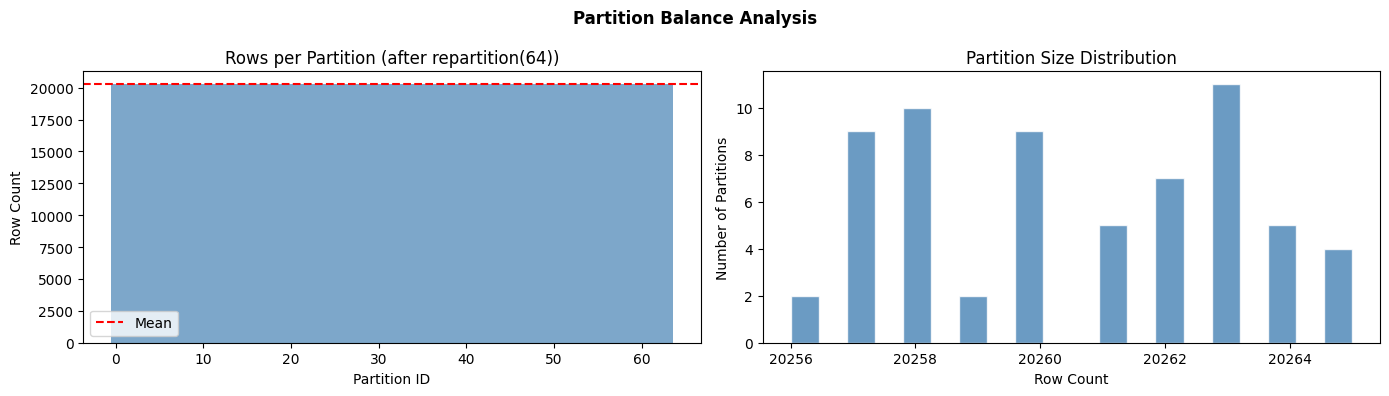

In [ ]:
# Partition size distribution , detect data skew after repartition.
# repartition(64) uses hash partitioning, so the distribution depends on
# the cardinality of the hash values across all rows.  A perfectly balanced
# dataset would have identical row counts per partition; real data rarely is.
df = spark.read.parquet(INPUT).repartition(64)

partition_sizes = (
    df.withColumn('pid', spark_partition_id())
      .groupBy('pid')
      .agg(F.count('*').alias('row_count'))
      .orderBy('pid')
      .toPandas()
)

print(f'Partitions: {len(partition_sizes)}')
print(f'Min rows  : {partition_sizes["row_count"].min():,}')
print(f'Max rows  : {partition_sizes["row_count"].max():,}')
print(f'Std dev   : {partition_sizes["row_count"].std():.0f}')
# A skew ratio close to 1.0 means the data is balanced.
# Ratios above ~3× warrant investigation; above ~10× need salting.
print(f'Skew ratio: {partition_sizes["row_count"].max() / partition_sizes["row_count"].min():.2f}x')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(partition_sizes['pid'], partition_sizes['row_count'],
            color='steelblue', alpha=0.7, width=1)
axes[0].axhline(partition_sizes['row_count'].mean(), color='red',
                linestyle='--', label='Mean')
axes[0].set_xlabel('Partition ID')
axes[0].set_ylabel('Row Count')
axes[0].set_title('Rows per Partition (after repartition(64))')
axes[0].legend()

axes[1].hist(partition_sizes['row_count'], bins=20, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Row Count')
axes[1].set_ylabel('Number of Partitions')
axes[1].set_title('Partition Size Distribution')

plt.suptitle('Partition Balance Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Predicate pushdown verification.
# Parquet stores row-group min/max statistics.  When Spark pushes a filter
# into the scan, it can skip entire row groups that can't satisfy the predicate
# without deserialising any data from them.
df = spark.read.parquet(INPUT)

print('=== Plan with predicate pushdown (filter before action) ===')
# Check the FileScan line in the plan: "PushedFilters: [IsNotNull(is_fraud), EqualTo(is_fraud,1)]"
# confirms the filter reached the Parquet reader level.
df.filter(F.col('is_fraud') == 1) \
  .select('amount', 'category', 'state') \
  .explain()

print('=== Column pruning: only read needed columns ===')
# Check the FileScan "ReadSchema" , it lists only the 3 requested columns,
# not all 23.  Parquet's columnar layout means the other columns are never
# read from disk at all.
df.select('amount', 'category', 'is_fraud').explain()

# Time: full scan vs pruned scan
t0 = time.perf_counter()
df.count()
t_full = time.perf_counter() - t0

t0 = time.perf_counter()
df.select('amount', 'category', 'is_fraud').count()
t_pruned = time.perf_counter() - t0

print(f'Full scan (23 cols)      : {t_full:.2f}s')
print(f'Pruned scan (3 cols)     : {t_pruned:.2f}s')
print(f'Column pruning speedup   : {t_full/t_pruned:.2f}x')

=== Plan with predicate pushdown (filter before action) ===
== Physical Plan ==
*(1) Project [amount#43937, category#43939, state#43945]
+- *(1) Filter (isnotnull(is_fraud#43938) AND (is_fraud#43938 = 1))
   +- *(1) ColumnarToRow
      +- FileScan parquet [amount#43937,is_fraud#43938,category#43939,state#43945] Batched: true, DataFilters: [isnotnull(is_fraud#43938), (is_fraud#43938 = 1)], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/mnt/c/Users/Elaf/Desktop/big-data-analytics-credit-card-transact..., PartitionFilters: [], PushedFilters: [IsNotNull(is_fraud), EqualTo(is_fraud,1)], ReadSchema: struct<amount:double,is_fraud:int,category:string,state:string>


=== Column pruning: only read needed columns ===
== Physical Plan ==
*(1) Project [amount#43937, category#43939, is_fraud#43938]
+- *(1) ColumnarToRow
   +- FileScan parquet [amount#43937,is_fraud#43938,category#43939] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/mnt/c/Use

## 11. End-to-End Benchmark Summary

Consolidate all measured speedups into a single comparison chart and configuration recommendation table.

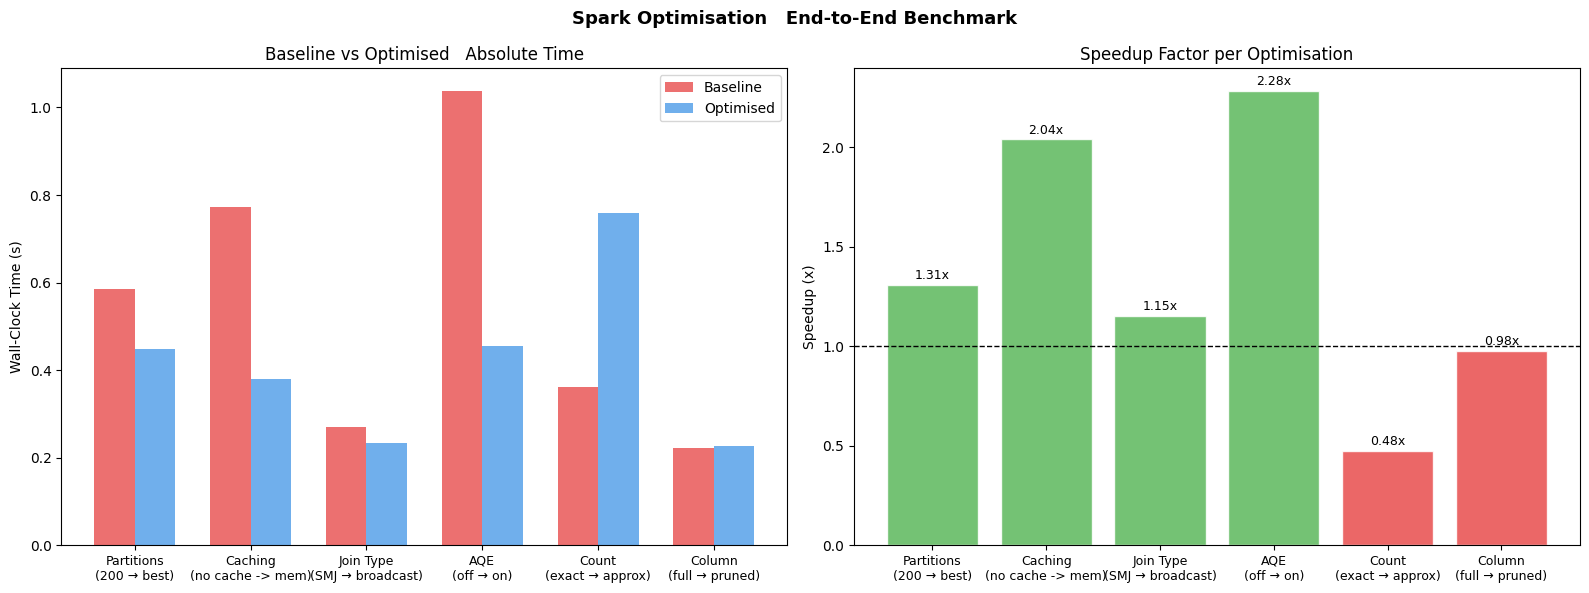

In [ ]:
# Collect all benchmark pairs (baseline, optimised, label)
benchmarks = [
    ('Partitions\n(200 -> best)', bench_results.get(200, max(bench_results.values())),
                                 bench_results[best_p], f'best={best_p}'),
    ('Caching\n(no cache -> mem)', cache_results['No Cache'],
                                   cache_results['MEMORY_AND_DISK'], 'MEMORY_AND_DISK'),
    ('Join Type\n(SMJ -> broadcast)', t_smj, t_bcast, 'broadcast'),
    ('AQE\n(off -> on)', t_no_aqe, t_aqe, 'AQE enabled'),
    ('Count\n(exact -> approx)', t_exact, t_approx, 'approx_count_distinct'),
    ('Column\n(full -> pruned)', t_full, t_pruned, '3 cols vs 23'),
]

labels     = [b[0] for b in benchmarks]
baselines  = [b[1] for b in benchmarks]
optimiseds = [b[2] for b in benchmarks]
speedups   = [b/o for b, o in zip(baselines, optimiseds)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw time comparison
x = np.arange(len(labels))
w = 0.35
axes[0].bar(x - w/2, baselines,  w, label='Baseline',  color='#E84C4C', alpha=0.8)
axes[0].bar(x + w/2, optimiseds, w, label='Optimised', color='#4C9BE8', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel('Wall-Clock Time (s)')
axes[0].set_title('Baseline vs Optimised   Absolute Time')
axes[0].legend()

# Speedup factors
colors_sp = ['#5CB85C' if s >= 1 else '#E84C4C' for s in speedups]
axes[1].bar(labels, speedups, color=colors_sp, alpha=0.85, edgecolor='white')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1)
axes[1].set_ylabel('Speedup (x)')
axes[1].set_title('Speedup Factor per Optimisation')
for i, s in enumerate(speedups):
    axes[1].text(i, s + 0.03, f'{s:.2f}x', ha='center', fontsize=9)
axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle('Spark Optimisation   End-to-End Benchmark', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
print('=' * 70)
print('         SPARK OPTIMISATION   CONFIGURATION RECOMMENDATIONS')
print('=' * 70)

recs = [
    ('spark.sql.shuffle.partitions',          str(best_p),    'Tuned from partition benchmark'),
    ('spark.sql.adaptive.enabled',            'true',         'Auto-coalesces small partitions'),
    ('spark.sql.adaptive.coalescePartitions.enabled', 'true', 'Merges post-shuffle partitions'),
    ('spark.sql.autoBroadcastJoinThreshold',  '20971520',     '20 MB   auto-broadcast small tables'),
    ('spark.serializer',                      'KryoSerializer','2-10x faster than Java default'),
    ('spark.io.compression.codec',            'lz4',          'Fast compression for shuffle'),
    ('spark.executor.memory',                 '4g',           'Adjust to cluster size'),
    ('spark.executor.memoryOverhead',         '512m',         'For native + Python off-heap'),
    ('spark.memory.fraction',                 '0.6',          'Default; increase for big joins'),
    ('spark.memory.storageFraction',          '0.5',          'Increase for cache-heavy jobs'),
    ('spark.speculation',                     'true',         'Re-launch straggler tasks'),
]

print(f'{"Config Key":<52} {"Value":<15} {"Reason"}')
print('-' * 70)
for key, val, reason in recs:
    print(f'{key:<52} {val:<15} {reason}')

print()
print('TECHNIQUES APPLIED')
print('  broadcast()     -> eliminated shuffle for small lookup joins')
print('  Accumulators    -> row-level audit without extra aggregation stage')
print('  Column pruning  -> read only needed columns from Parquet')
print('  Early filter    -> predicate pushdown to reduce scan volume')
print('  cache()         -> avoid re-reading Parquet for reused DataFrames')
print('  coalesce()      -> narrow reduce of partitions before write/collect')
print('  approx_count_distinct -> 10-100x faster than exact countDistinct')
print('  AQE             -> runtime plan adaptation, no manual tuning needed')
print('=' * 70)

         SPARK OPTIMISATION   CONFIGURATION RECOMMENDATIONS
Config Key                                           Value           Reason
----------------------------------------------------------------------
spark.sql.shuffle.partitions                         400             Tuned from partition benchmark
spark.sql.adaptive.enabled                           true            Auto-coalesces small partitions
spark.sql.adaptive.coalescePartitions.enabled        true            Merges post-shuffle partitions
spark.sql.autoBroadcastJoinThreshold                 20971520        20 MB   auto-broadcast small tables
spark.serializer                                     KryoSerializer  2-10x faster than Java default
spark.io.compression.codec                           lz4             Fast compression for shuffle
spark.executor.memory                                4g              Adjust to cluster size
spark.executor.memoryOverhead                        512m            For native + Python off-heap

In [31]:
spark.stop()
print('Spark session stopped.')

Spark session stopped.
